In [2]:
# Instalación de LaTeX para renderizado tipográfico
#!sudo apt-get update -qq
#!sudo apt-get install -qq texlive-latex-extra texlive-fonts-recommended dvipng cm-super

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm

# ── Configuración global de estilo matplotlib (igual que en clases anteriores) ──
plt.rcParams.update({
    "text.usetex"        : True,
    "font.family"        : "serif",
    "font.serif"         : ["Computer Modern Roman"],
    "font.size"          : 14,

    "axes.labelsize"     : 16,
    "axes.titlesize"     : 18,
    "xtick.labelsize"    : 12,
    "ytick.labelsize"    : 12,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction"    : "in",
    "ytick.direction"    : "in",

    "grid.color"         : "gray",
    "grid.linewidth"     : 0.3,
    "grid.alpha"         : 0.3,
    "grid.linestyle"     : "--",

    "figure.dpi"         : 120,
    "axes.spines.top"    : False,
    "axes.spines.right"  : False,
    "savefig.bbox"       : "tight",
    "savefig.dpi"        : 300,
})
print("Configuración OK")

Configuración OK


# Contexto
Queremos resolver numericamente la ecuación del calor sobre la esfera $S^2$. Para ello utilicemos la parametrización

$$
\left\{
\begin{aligned}
x &= \sin\varphi\cos\theta,\\
y &= \sin\varphi\sin\theta,\\
z &= \cos\varphi,
\end{aligned}
\right.
$$

con $0\leq\varphi\leq\pi,
\qquad
0\leq\theta<2\pi.$

Así la ecuación del calor es

$$
\frac{\partial u}{\partial t}
=
\frac{1}{\sin\varphi}
\frac{\partial}{\partial\varphi}
\left(
\sin\varphi
\frac{\partial u}{\partial\varphi}
\right)
+
\frac{1}{\sin^2\varphi}
\frac{\partial^2u}{\partial\theta^2}.
$$

Y tomemos como condición inicial

$$
u(\varphi,\theta,0) = u_0(\varphi,\theta) = e^{-5\left((\varphi-\varphi_0)^2+(\theta-\theta_0)^2\right)}
$$

con $\varphi_0=\frac{\pi}{2}$ y $\theta_0=\frac{3\pi}{4}$

Discreticemos nuestro dominio con una malla uniforme, partiendo el dominio de $\varphi$ en $40$ partes y el de $\theta$ en $80$


In [3]:
# 1) Parametros de la malla

N_phi = 41    # Resolución en colatitud φ (0 a pi). Usamos 41 para tener el ecuador exacto.
N_theta = 80  # Resolución en longitud θ (0 a 2pi)
alpha = 1.0   # Coeficiente de difusividad térmica

# Creación de los vectores de coordenadas
phi = np.linspace(0, np.pi, N_phi)
theta = np.linspace(0, 2 * np.pi, N_theta)

# Malla 2D (Phi y Theta)
Phi, Theta = np.meshgrid(phi, theta, indexing='ij')

dphi = phi[1] - phi[0]
dtheta = theta[1] - theta[0]

# Condición de estabilidad CFL para métodos explícitos
min_sin_phi = np.sin(dphi) # Tomamos el primer nodo interior para evitar el 0
dt = 0.25 * min(dphi**2, (dtheta * min_sin_phi)**2) / alpha
n_steps = 5000 # Iteraciones totales en el tiempo

# Momentos específicos (iteraciones) que queremos capturar para graficar
snapshots = [0, 500, 2000, n_steps]
u_snapshots = []

In [4]:
# 2) Condiciones iniciales

# Ubicamos un punto de calor en el ecuador (phi = pi/2) y en la cara frontal (theta = 3pi/4).
phi_0 = np.pi / 2
theta_0 = (3 * np.pi) / 4
# Distribución de temperatura inicial u(φ, θ, t=0)
u = np.exp(-5 * ((Phi - phi_0)**2 + (Theta - theta_0)**2))

In [5]:
# 3) Precalculos de optimización

# Aislamos los nodos interiores (excluyendo polos) para el bucle
phi_interior = phi[1:-1, np.newaxis]
# Término cot(φ) = cos(φ)/sin(φ) de la expansión de la derivada respecto a φ
cot_phi = np.cos(phi_interior) / np.sin(phi_interior)
# Término 1/sin^2(φ) para la derivada respecto a θ
csc2_phi = 1.0 / (np.sin(phi_interior)**2)

#Solucion numerica
A continuación, tras plantear nuestra EDP, vamos a proceder a realizar una aproximación númerica de la temperatura en nuestros nodos utilizando el método de diferencias finitas centradas

In [6]:
#4) Solucion numerica a la EDP

for step in range(n_steps+1):
    # Guardar estado actual si coincide con los snapshots requeridos
    if step in snapshots:
        u_snapshots.append(u.copy())

    u_new = u.copy()

    # Diferencias finitas centrales (solo para los nodos interiores: índice 1 a N_phi-2)

    # Derivada segunda respecto a φ: ∂²u/∂φ²
    u_phi_phi = (u[2:, :] - 2*u[1:-1, :] + u[:-2, :]) / (dphi**2)

    # Derivada primera respecto a φ: ∂u/∂φ
    u_phi = (u[2:, :] - u[:-2, :]) / (2 * dphi)

    # Derivada segunda respecto a θ: ∂²u/∂θ²
    u_theta_theta = (np.roll(u, -1, axis=1)[1:-1, :] - 2*u[1:-1, :] + np.roll(u, 1, axis=1)[1:-1, :]) / (dtheta**2)

    # Aplicación del Operador de Laplace-Beltrami discretizado (de la Sección 6 del PDF)
    laplacian = u_phi_phi + cot_phi * u_phi + csc2_phi * u_theta_theta

    # Avance en el tiempo (Euler explícito): u(t+1) = u(t) + dt * α * Δ_g(u)
    u_new[1:-1, :] = u[1:-1, :] + alpha * dt * laplacian

    # --- Condiciones de Contorno para los Polos ---
    # Físicamente, el polo es un solo punto. Matemáticamente en nuestra matriz,
    # Es toda la fila u[0, :] y u[-1, :]. Para evitar divisiones por cero
    # Para mantener el modelo físico, asignamos a todos los puntos del polo el
    # valor promedio del anillo latitudinal inmediatamente adyacente.

    u_new[0, :] = np.mean(u_new[1, :])   # Polo Norte (φ = 0)
    u_new[-1, :] = np.mean(u_new[-2, :]) # Polo Sur (φ = π)

    # Actualizar la matriz para la siguiente iteración
    u = u_new

# Visualización
Finalmente, vamos a visualizar nuestros resultados mediante un conjunto de gráficas que nos muestran la manera en cómo evoluciona la dispersión del calor en nuestro dominio. Para ello capturemos la dispersión el instante inicial, tras 500, 2000 y 5000 pasos (cabe aclarar que el color está normalizado).

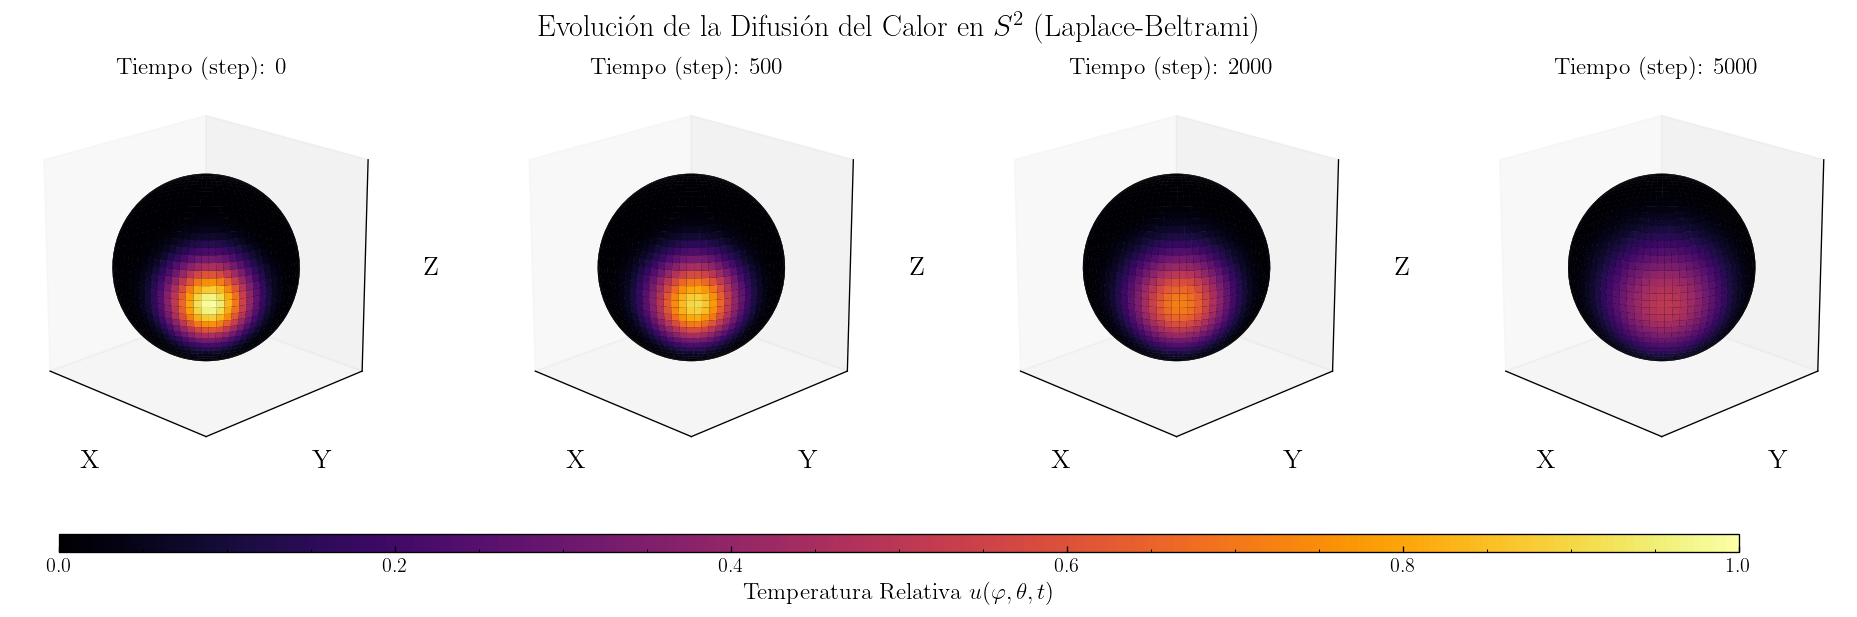

In [7]:
# 5) Visualización

# Conversión de Coordenadas Esféricas a Cartesianas para el ploteo 3D
X = np.sin(Phi) * np.cos(Theta)
Y = np.sin(Phi) * np.sin(Theta)
Z = np.cos(Phi)

# Configurar la ventana de la figura
fig = plt.figure(figsize=(20, 5))
fig.suptitle('Evolución de la Difusión del Calor en $S^2$ (Laplace-Beltrami)', fontsize=18, y=1.0)

# Normalizador de color global para que todas las esferas compartan la misma escala (0 a 1)
norm = plt.Normalize(vmin=0, vmax=1.0)
cmap = cm.inferno # Paleta de colores ideal para representar calor

# Definir el color de la sombra como un array 3D (M, N, 4) para plot_surface
shadow_color_rgba = np.array([0, 0, 0, 0.2])
facecolors_shadow = np.full((X.shape[0], X.shape[1], 4), shadow_color_rgba)

for idx, (step, u_snap) in enumerate(zip(snapshots, u_snapshots)):
    ax = fig.add_subplot(1, len(snapshots), idx + 1, projection='3d')

    # Mapear los valores de temperatura de esta iteración a colores
    colors = cmap(norm(u_snap))

    # Dibujar la superficie
    surf = ax.plot_surface(X, Y, Z, facecolors=colors, rstride=1, cstride=1,
                           linewidth=0, antialiased=True, shade=False)

    ax.set_title(f'Tiempo (step): {step}', fontsize=14)

    # Mostrar los ejes por defecto (formando una caja)
    # Desactivar la cuadrícula y los números
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    # Fijamos el ángulo de la cámara para ver bien el punto caliente (frente y un poco arriba)
    ax.view_init(elev=20, azim=135)

    ax.set_xlim([-1.2, 1.2])
    ax.set_ylim([-1.2, 1.2])
    ax.set_zlim([-1.2, 1.2])

    ax.set_box_aspect([1,1,1]) # Asegurar que la esfera no se vea aplastada

# Añadir una barra de color en la parte inferior
m = cm.ScalarMappable(cmap=cmap, norm=norm)
m.set_array([])
cbar_ax = fig.add_axes([0.15, 0.1, 0.7, 0.03])
cbar = fig.colorbar(m, cax=cbar_ax, orientation='horizontal')
cbar.set_label(r'Temperatura Relativa $u(\varphi, \theta, t)$', fontsize=14)

plt.subplots_adjust(bottom=0.25)
plt.show()

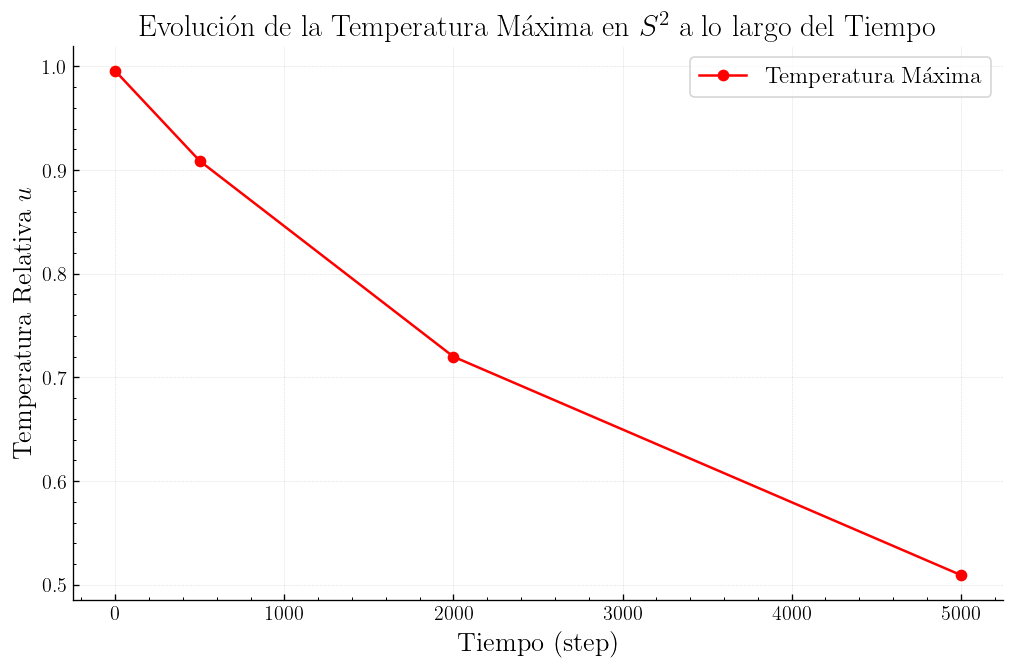

In [8]:
# Obtener los valores de tiempo (iteraciones) de los snapshots
time_steps = snapshots

# Calcular la temperatura máxima para cada snapshot
max_temps = [np.max(u_snap) for u_snap in u_snapshots]

# Crear la figura y los ejes para la Temperatura Máxima
plt.figure(figsize=(10, 6))

# Plotear la temperatura máxima
plt.plot(time_steps, max_temps, label='Temperatura Máxima', marker='o', linestyle='-', color='red')

# Añadir títulos y etiquetas
plt.title('Evolución de la Temperatura Máxima en $S^2$ a lo largo del Tiempo')
plt.xlabel('Tiempo (step)')
plt.ylabel('Temperatura Relativa $u$')
plt.legend()
plt.grid(True)
plt.show()